# Data Analysis

In [13]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "scripts"))
from build_points_table import build_and_save_points_table
from class_imbalance import plot_class_imbalance
from taxonomy_separability import run_separability_probe

## Build the points table

In [14]:
df = build_and_save_points_table()

/home/bruno/radar_machine_learning_ws/results/points_table.parquet already exists, skipping build


## Class imbalance

Loaded 1443816 points from /home/bruno/radar_machine_learning_ws/results/points_table.parquet
503759 object instances
                        count   pct
label_name                         
car                    214395  42.6
pedestrian_group       126517  25.1
pedestrian              79372  15.8
bicycle                 32881   6.5
truck                   31395   6.2
bus                      9483   1.9
other_dynamic            4558   0.9
large_vehicle            3330   0.7
motorized_two_wheeler    1617   0.3
animal                    154   0.0
train                      57   0.0
Saved plot to /home/bruno/radar_machine_learning_ws/results/class_counts.png


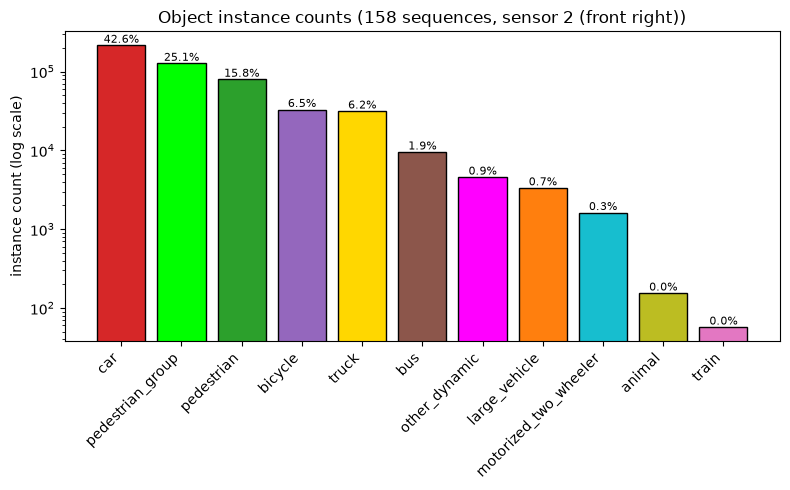

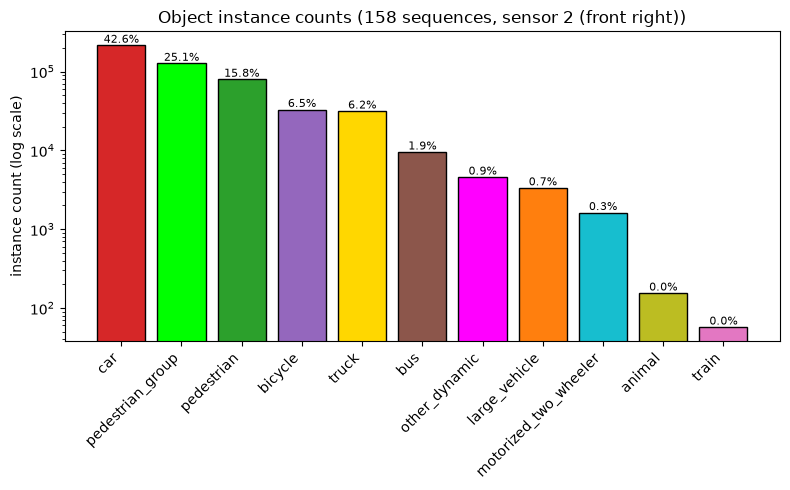

In [15]:
counts, fig = plot_class_imbalance()
fig

**Decision:** reduce to 6 classes, matching the official `radar_scenes` package's own
`ClassificationLabel` grouping (`radar_scenes/labels.py`). This isn't just a
convenience merge, it's the dataset authors' own recommended scheme for ML tasks:

```
car               -> car
large_vehicle      -> large_vehicle
truck              -> large_vehicle
bus                -> large_vehicle
train              -> large_vehicle
bicycle            -> two_wheeler
motorized_two_wheeler -> two_wheeler
pedestrian         -> pedestrian
pedestrian_group   -> pedestrian_group
static             -> (dropped, not trained on)
animal             -> (dropped, not trained on)
other_dynamic       -> (dropped, not trained on)
```

`animal` and `other_dynamic` are dropped rather than merged because they're low-signal catch-all classes (officially mapped to None) rather than coherent categories for a classifier.

This assumes train/truck/bus share a similar-enough radar
signature to large_vehicle that merging doesn't destroy separability. Planned
EDA (RCS/point-count distributions per class) should confirm with data rather than just
trusting the assumption. Revisit if train looks radically different. However, the train label count is too low and is essentially noise.


Merge truck, bus, and large_vehicle into a single large_vehicle class if the logistic-regression and random-forest probes, trained on the full feature vector (RCS, compensated Doppler, x_rel, y_rel, doppler_spread), shows poor held-out separability between them. Support the decision with models, rather than relying on 1D histogram overlap.

# Separability probing

class weights: {'truck': 1.0, 'bus': 3.3326259946949603, 'large_vehicle': 9.457282649604817}

=== logistic_regression ===
               precision    recall  f1-score   support

          bus       0.67      0.62      0.64      1943
large_vehicle       0.11      0.51      0.18       673
        truck       0.79      0.50      0.61      6267

     accuracy                           0.52      8883
    macro avg       0.52      0.54      0.48      8883
 weighted avg       0.71      0.52      0.58      8883

per-class one-vs-rest ROC-AUC:
  bus: 0.820
  large_vehicle: 0.693
  truck: 0.637
pairwise (one-vs-one) ROC-AUC:
  large_vehicle vs truck: 0.632
  large_vehicle vs bus: 0.888
  truck vs bus: 0.657
majority-class baseline (truck): 0.706 accuracy
Saved /home/bruno/radar_machine_learning_ws/results/taxonomy_confusion_matrix_logistic_regression.png

=== random_forest ===
               precision    recall  f1-score   support

          bus       0.53      0.62      0.57      1943
large_veh

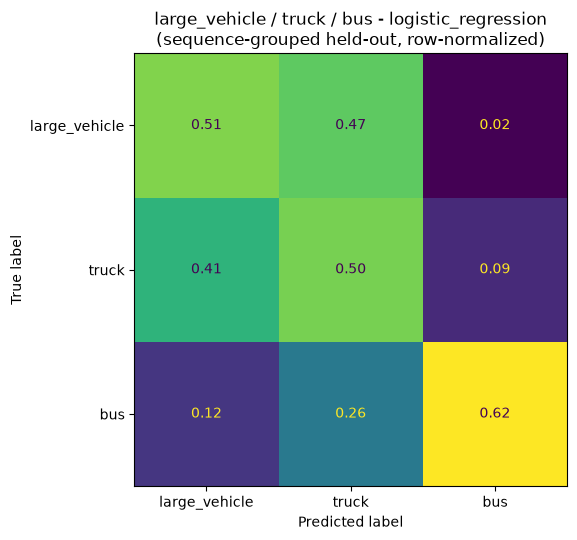

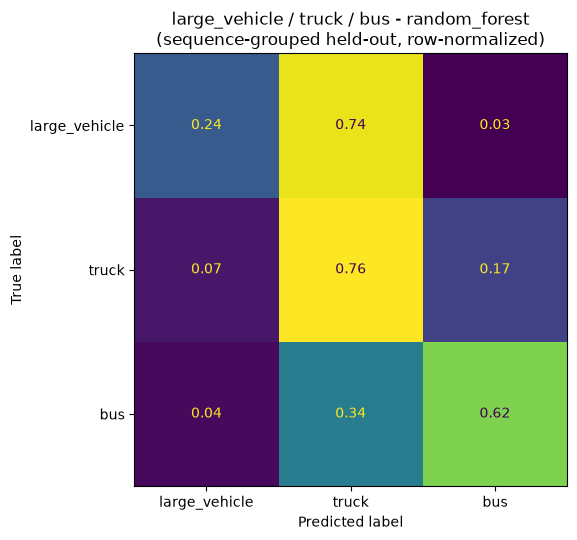

In [16]:
results = run_separability_probe(df)

large_vehicle / truck: Strong case for merging. Their pairwise AUC is the weakest of the three (0.632), and the Random-Forest confusion matrix shows large_vehicle being classified as truck 74% of the time. Both metrics point to the same conclusion, providing consistent evidence rather than noise.

bus: The evidence is mixed. bus is well separated from large_vehicle (AUC 0.888), but poorly separated from truck (AUC 0.657, with 34% RF confusion). Therefore, the data does not support either treating bus as clearly distinct from both classes or merging it with both. Whether to merge bus is a design decision. 

The decision is to merge large_vehicle into truck (target class name kept as `large_vehicle`, per the official scheme). Keep `bus` as its own class.

bus is kept separate despite the mixed pairwise, `run_separability_probe` trains on 5 hand-aggregated scalars (median RCS, median Doppler, two extents, one spread value) rather than full per-instance distributions. Actual classifier will use paper-faithful per-instance histograms. Revisit this later: if bus is still heavily confused with large_vehicle/truck in the real classifier's confusion matrix once real features are used, merge it in then, don't decide it now with a crude probe.